## Code Setup ##

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
import glob 
import os

## Simulation Parameters ##

In [2]:
# Rate Constants in s-1 unless indicated as m-1s-1
kC0C1 = 17.1e6 #m-1s-1
kC1C0 = 157
kC1C2 = 3.24e6 #m-1s-1
kC2C1 = 3.76e3
kC2O = 14.9e3
kOC2 = 4e3
kC1C3 = 1.53e3
kC3C1 = 408
kC2C4 = 502
kC4C2 = .377
kOC5 = 121
kC5O = 191
kC3C4 = .611e6 #m-1s-1
kC4C3 = 2
kC4C5 = 1.59e3
kC5C4 = 899e3

In [3]:

N = 50 #num channels
g = 8.5e-12 #conductance
V_hold = -60e-3 #holding potential
V_rev = 0  #reversal potential

##Agonist Parameters
agonist_conc = 1e-3 
pulse_start = 0 #Start at beginning
pulse_end = 0.001 #end at 1ms


##Time Parameters
t_max = 0.01 # 10ms
n_samples = 1000 #Time interval defined as 10microseconds, across 10ms, means 10,000microseconds and 1000 samples
t_eval = np.linspace(0,t_max,n_samples)
time_ms = t_eval * 1e3

num_traces = 1000

## Simulation Helper Functions ## 

In [4]:
def agonist_conc_t(t):
    return agonist_conc if (pulse_start <= t <= pulse_end) else 0.0


def rates_for_state(state, t):
    if state == 'C0':
        return [('C1', kC0C1 * agonist_conc_t(t))]
    elif state == 'C1':
        return [('C0', kC1C0), ('C3', kC1C3),('C2',kC1C2 * agonist_conc_t(t))]
    elif state == 'C2':
        return [('C1', kC2C1),('C4',kC2C4),('O',kC2O)]
    elif state == 'C3':
        return [('C1', kC3C1), ('C4', kC3C4 * agonist_conc_t(t))]
    elif state == 'C4':
        return [('C2', kC4C2), ('C5', kC4C5),('C3',kC4C3)]
    elif state == 'C5':
        return [('O', kC5O), ('C4', kC5C4)]
    elif state == 'O':
        return [('C2', kOC2), ('C5', kOC5)]
    else:
        raise ValueError

def next_pulse_boundary_after(t):
    boundaries = []
    if t < pulse_start:
        boundaries.append(pulse_start)
    if t < pulse_end:
        boundaries.append(pulse_end)
    return min(boundaries) if boundaries else np.inf

def simulate_one_channel(t_max):
    t = 0.0
    state = 'C0'
    times = [t]
    states = [state]
    while t < t_max:
        trans = rates_for_state(state, t) #[(1,0)] = trans
        rates = np.array([r for (_, r) in trans])
        a0 = rates.sum()
        boundary = next_pulse_boundary_after(t)
        if a0 <= 0:
            t = min(boundary, t_max)
            times.append(t)
            states.append(state)
            if t >= t_max:
                break
            continue
        dt = -np.log(np.random.rand()) / a0
        if t + dt > min(boundary, t_max):
            t = min(boundary, t_max)
            times.append(t)
            states.append(state)
            continue
        t = t + dt
        r = np.random.rand() * a0
        cum = 0.0
        chosen = None
        for i, (_, rate) in enumerate(trans):
            cum += rate
            if r <= cum:
                chosen = trans[i][0]
                break
        if chosen is None:
            chosen = trans[-1][0]
        state = chosen
        times.append(t)
        states.append(state)
    if times[-1] < t_max:
        times.append(t_max)
        states.append(states[-1])
    return np.array(times), np.array(states, str)


def events_to_sampled_open(times, states, t_eval):
    sampled = np.zeros_like(t_eval, dtype=int)
    idx = 0
    for i, tt in enumerate(t_eval):
        while idx + 1 < len(times) and times[idx + 1] <= tt:
            idx += 1
        sampled[i] = 1 if states[idx] == 'O' else 0
    return sampled

## Single Channel Example ## 

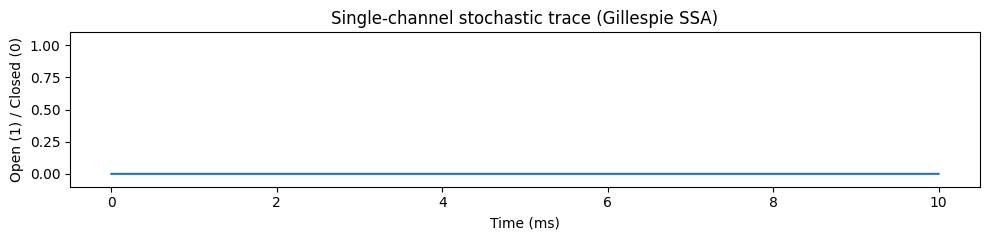

In [5]:
# # Single-channel example
np.random.seed(1)
times1, states1 = simulate_one_channel(t_max)
open_trace1 = events_to_sampled_open(times1, states1, t_eval)

plt.figure(figsize=(10,2.5))
plt.step(time_ms, open_trace1, where='post')
plt.ylim(-0.1, 1.1)
plt.xlabel('Time (ms)')
plt.ylabel('Open (1) / Closed (0)')
plt.title('Single-channel stochastic trace (Gillespie SSA)')
plt.tight_layout()
plt.show()

# Simulate N channels
open_counts = np.zeros_like(t_eval, dtype=int)
for n in range(N):
    times_n, states_n = simulate_one_channel(t_max)
    open_counts += events_to_sampled_open(times_n, states_n, t_eval)

I = open_counts * g * (V_hold - V_rev)
I_pA = I * 1e12

## Run EPSCs ## 

This section was run 4 times with 4 different agonist concentrations, changing the name of the Excel file each run at the end

In [6]:

# # Simulate EPSCs
# all_traces = []

# for trace_id in range(num_traces):
#     open_counts = np.zeros_like(t_eval, dtype=int)

#     # simulate N independent channels and sum their openings
#     for n in range(N):
#         times_n, states_n = simulate_one_channel(t_max)
#         open_counts += events_to_sampled_open(times_n, states_n, t_eval)

#     # convert to current
#     I = open_counts * g * (V_hold - V_rev)  # Amps
#     I_pA = I * 1e12                         # picoAmps

#     all_traces.append(I_pA)

# # Convert to DataFrame: each column is one trace, rows are timepoints
# df = pd.DataFrame(np.array(all_traces).T, index=t_eval)

# plt.xlabel("Time (ms)")
# plt.ylabel("Current (pA)")
# for col in df.columns:
#     plt.plot(df.index*1e3,df[col],alpha=.3)
# template = np.mean(df,axis=1)
# plt.plot(df.index*1e3,template)
# plt.title("Veruki GluGei99 Replica, 1000 EPSCs")
# plt.show()
# df.columns = [f"trace_{i+1}" for i in range(num_traces)]


# df = df*-1
# df.to_excel(f"Geiger_replica_EPSCs/Geiger_replica_EPSCs_{str(int(agonist_conc*1000))}mM.xlsx")

## Visualizing the EPSC templates together, stylized like Geiger's ##

In [42]:
folder_path = 'C:\\Users\\jawad\\Downloads\\Python-EPSC-NSFA-Pipeline\\experimental-scripts\\Geiger_replica_EPSCs'

excel_files = glob.glob(os.path.join(folder_path,"*.xlsx"))
templates = []
for file in excel_files:
    if "all" in file: 
        print("Skipping full df")
    else:
        print(f"Reading {file}")
        EPSCs = pd.read_excel(file) 
        template = np.mean(EPSCs, axis=1)
        templates.append(template)


print(templates)
     
    

Skipping full df
Reading C:\Users\jawad\Downloads\Python-EPSC-NSFA-Pipeline\experimental-scripts\Geiger_replica_EPSCs\Geiger_replica_EPSCs_100mM.xlsx
Reading C:\Users\jawad\Downloads\Python-EPSC-NSFA-Pipeline\experimental-scripts\Geiger_replica_EPSCs\Geiger_replica_EPSCs_1mM.xlsx
Reading C:\Users\jawad\Downloads\Python-EPSC-NSFA-Pipeline\experimental-scripts\Geiger_replica_EPSCs\Geiger_replica_EPSCs_3mM.xlsx
Reading C:\Users\jawad\Downloads\Python-EPSC-NSFA-Pipeline\experimental-scripts\Geiger_replica_EPSCs\Geiger_replica_EPSCs_5mM.xlsx
[0       2.26542
1       5.20812
2       7.67244
3       9.70581
4      11.36637
         ...   
994     0.01479
995     0.01530
996     0.01581
997     0.01530
998     0.01530
Length: 999, dtype: float64, 0      0.00153
1      0.01734
2      0.06375
3      0.12801
4      0.22746
        ...   
994    0.01173
995    0.01071
996    0.01071
997    0.01122
998    0.01122
Length: 999, dtype: float64, 0      0.02193
1      0.15555
2      0.44676
3      0.874

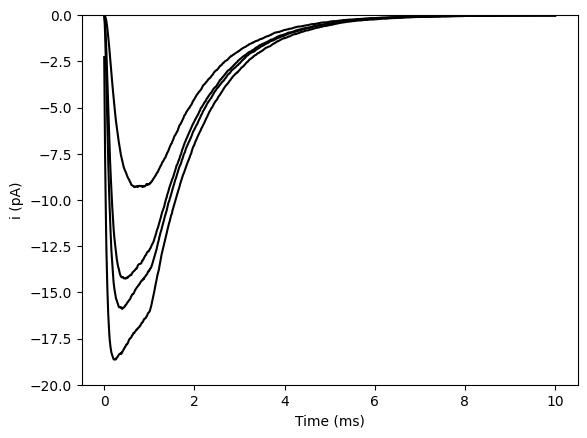

In [50]:
time = np.linspace(0,10,999)
for template in templates:
    plt.plot(time,template*-1,color="black")
    plt.xlabel("Time (ms)")
    plt.ylabel("i (pA)")
    plt.ylim(-20,0)

plt.show()

## Run NSFA Analysis ##

### This function creates NSFA matrics for all combinations of parameters selected ###

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import Scripts.EPSC_Webapp.EPSC_App_Connection as EPSC_App_Connection
import Scripts.EPSC_Webapp.EPSC_preprocessing as EPSC_preprocessing
from tqdm import tqdm
import seaborn as sns
import itertools
import matplotlib.lines as mlines

def matrix_generator(params,first_sheet=True,debug=False,save_figs=True): #Where params is a dictionary of parameters
    matrix = []
    if not params["direct_df_input"]:
        if params["file_name"].split('.')[-1] == 'xlsx':
            excel_file = pd.ExcelFile(f"{params['file_name']}")
        if first_sheet:
            sheet_names = [excel_file.sheet_names[0]]
        else:
            sheet_names = excel_file.sheet_names
    else:
        sheet_names = params["sheet_names"]
    workflow_report = {'files processed':sheet_names}
    for sheet_name in tqdm(sheet_names, desc="Processing Excel files", unit="file"):
        workflow_report[sheet_name] = {}
        if not params["direct_df_input"]:
            epscs = pd.read_excel(params["file_name"],sheet_name=sheet_name)
        else:
            epscs = params["EPSCs"]
        epscs = epscs.to_numpy()
        folder_name = params["folder_name"]
        if params["recording_duration"] == None:
            time_duration = 16  #ms
        else:
            time_duration = params["recording_duration"]
        num_samples = epscs.shape[0]
        print(f"Shape of EPSCs: {epscs.shape}")
        ##Plotting the raw EPSCs, unchanged

        if save_figs:
            fig, axs = plt.subplots(1, 1)
            timepoints = np.linspace(0, time_duration, num_samples)
            for i in range(epscs.shape[1]):
                axs.plot(timepoints, epscs[:, i], label=f'Trace {i + 1}')
            axs.set_xlabel('Time (ms)', fontsize=13)
            axs.set_ylabel('Current (pA)', fontsize=13)
            axs.set_title('EPSCs Before Processing')
            plt.savefig(f'{folder_name}Raw_EPSCs_{sheet_name}.png')
            workflow_report[sheet_name]['raw_epsc_fig_path'] = f'{folder_name}Raw_EPSCs_{sheet_name}.png'


        ##Implementing alignment options
        #for each alignment option:
        for alignment_type in params["alignment"]:
            workflow_report[sheet_name][alignment_type] = {}
            if alignment_type == "peak":
                alignment_processed, peak_index = EPSC_preprocessing.align_peaks(epscs)
                start_point = peak_index


            elif alignment_type == "midpoint":
                alignment_processed = EPSC_preprocessing.align_midpoint(epscs)
                start_point = 15
            elif alignment_type == "max_dv_dt":
                alignment_processed = EPSC_preprocessing.align_dv_dt(epscs,debug=debug)
                start_point = 15
            elif alignment_type == "None":
                alignment_processed = epscs

            if save_figs:
                fig, axs = plt.subplots(1, 2)
                timepoints = np.linspace(0, time_duration, num_samples)
                for i in range(epscs.shape[1]):
                    axs[0].plot(timepoints, epscs[:, i], label=f'Trace {i + 1}')
                    axs[1].plot(timepoints, alignment_processed[:, i], label=f'Trace {i + 1}')
                axs[0].axvline(x=15 * (time_duration/num_samples), color='red', linestyle='--', linewidth=2, label='Alignment Point')
                axs[0].set_xlabel('Time (ms)', fontsize=13)
                axs[0].set_ylabel('Current (pA)', fontsize=13)
                axs[0].set_title('EPSCs Before Alignment')
                axs[1].axvline(x=15 *  (time_duration/num_samples), color='red', linestyle='--', linewidth=2, label='Alignment Point')
                axs[1].set_xlabel('Time (ms)', fontsize=13)
                axs[1].set_ylabel('Current (pA)', fontsize=13)
                axs[1].set_title(f'EPSCs After Alignment: {alignment_type}')
                plt.savefig(f'{folder_name}{alignment_type}_Alignment.png')
            if debug:
                plt.show()
                workflow_report[sheet_name][alignment_type]['image'] = f'{folder_name}{alignment_type}_Alignment.png'
            #Create the template
            timepoints, template = EPSC_App_Connection.create_template(alignment_processed,time_duration,num_samples)
            # workflow_report[sheet_name][alignment_type]['template_data'] = template
            workflow_report[sheet_name][alignment_type]['template_image'] = f'{folder_name}{alignment_type}_Alignment.png'
            template_max = np.max(template)
            peak_index = np.argmax(template)
            # print(f"Template max: {template_max} and {template[peak_index]}")

            #Set some variables for the analysis
            pool_indices = EPSC_App_Connection.create_pool_indices(alignment_processed, peak_index)
            num_traces = alignment_processed.shape[1]
            raw_sorted = EPSC_App_Connection.sort_EPSCs_by_size(alignment_processed, peak_index)
            endPoint = template.shape[0] - 1

            #For each scaling option
            for scaling_type in params["scaling"]:
                if scaling_type == "minimize_error":
                    residuals_array = EPSC_App_Connection.create_residuals(num_traces,raw_sorted,template,
                                                                                                  error_minimize=True,debug=debug)

                elif scaling_type == "peak_scaling_at_peak_time":
                    residuals_array = EPSC_App_Connection.create_residuals(num_traces, raw_sorted,
                                                                                                  template,
                                                                                                  error_minimize=False,peak_to_peak=False)


                elif scaling_type == "peak_to_peak_scaling":
                    residuals_array = EPSC_App_Connection.create_residuals(num_traces, raw_sorted,template,

                                                                                                    error_minimize=False,peak_to_peak=True)
                elif scaling_type == "raw":
                    residuals_array = EPSC_App_Connection.raw_residuals(raw_sorted,template)
                #For each analysis start point option
                for start_option in params["analysis_start_point"]:
                    segment_indices = EPSC_App_Connection.create_segment_indices(template, start_option)


                    if debug:
                        plt.figure()
                        plt.plot(timepoints, template, color='blue')
                        plt.title("Segment Validation on Template")
                        plt.xlabel("Time (ms)")
                        plt.ylabel("Current (pA)")
                        for index in segment_indices:
                            plt.axvline(x=(peak_index + index) * (time_duration/num_samples), color='red', linestyle='--', linewidth=1)
                        plt.savefig("Segments_Validation.png")
                        workflow_report[sheet_name][start_option] = 'Segments_Validation.png'
                        plt.show()
                    # if start_option == "peak_start":
                    #Run mean variance with that start point
                    means = EPSC_App_Connection.mean_calculation(raw_sorted, start_index=peak_index, endPoint=endPoint, segment_indices=segment_indices,
                                             analysis_type=3)
                    vars = EPSC_App_Connection.var_calculation(peak_index, residuals_array, segment_indices, pool_indices, endPoint, 3)


                    # elif start_option == "alignment_point":
                    #
                    #      means = EPSC_App_Connection.mean_calculation(raw_sorted, start_index=start_point, endPoint=endPoint, segment_indices=segment_indices,
                    #                               analysis_type=3)
                    #      vars = EPSC_App_Connection.var_calculation(start_point, residuals_array, segment_indices, pool_indices, endPoint, 3)
                    #
                    #     #Run mean variance with that alignment

                    #Derive i, n values for linear and parabolic
                    fit_parabola, roots, initial_slope = EPSC_App_Connection.fitting_parabola(means, vars,force_linear=False)
                    n = roots[0] / initial_slope
                    lin_fit_parabola, lin_roots, lin_initial_slope = EPSC_App_Connection.fitting_parabola(means, vars,force_linear=True)
                    matrix_entry = {"cell_name": sheet_name,"alignment":alignment_type,"analysis_start_point":start_option,"scaling":scaling_type,"linear_i":lin_initial_slope,"parabolic_i":initial_slope,"num_channels":n,"template_max":template_max}
                    matrix.append(matrix_entry)
                    if save_figs:
                        print("Saving figs...")
                        fig, axs = plt.subplots(1, 1)
                        axs.scatter(means, vars, color='green')
                        for idx,item in enumerate(means):
                            axs.text(means[idx],vars[idx],idx)
                        sorter = np.sort(means)
                        roots = fit_parabola.r
                        if len(roots) > 1:
                            x_vals = np.linspace(min(roots) - 1, max(roots) + 1, 500)
                            axs.plot(x_vals, fit_parabola(x_vals), color='black')
                        else:
                            axs.plot(sorter,lin_fit_parabola(sorter),color='red')
                        if "mean_channels" in params:
                            #Plot the idealized parabola
                            N = params["mean_channels"]
                            i = params["theoretical_current"]
                            ideal_parabola = np.poly1d([-1/N,i,0])
                            roots = ideal_parabola.r
                            x_vals = np.linspace(min(roots) - 1, max(roots) + 1, 500)
                            axs.plot(x_vals,ideal_parabola(x_vals),color='blue')
                        # axs.plot(sorter[0:5], lin_fit_parabola(sorter)[0:5], color='red')
                        axs.set_title("Variance vs Mean")
                        axs.set_xlabel("Mean Current (pA)")
                        axs.set_ylabel("Current variance (pA^2)")

                        plt.savefig(f"{params['folder_name']}/{alignment_type}_{start_option}_{scaling_type}_{sheet_name}.png")
                        plt.show()
                    print(matrix_entry)
    return matrix


### Combining all files (different concentrations of Glutamate) into one ### 

In [7]:
folder_path = 'C:\\Users\\jawad\\Downloads\\Python-EPSC-NSFA-Pipeline\\experimental-scripts\\Geiger_replica_EPSCs'

excel_files = glob.glob(os.path.join(folder_path,"*.xlsx"))
output_path = os.path.join(folder_path, "all_geiger_epscs.xlsx")
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for file in excel_files:
        sheet_name = os.path.splitext(os.path.basename(file))[0]
        df = pd.read_excel(file)
        df.to_excel(writer,sheet_name=sheet_name[:31],index=False)



### Bootstrap Analysis Protocol ###

In [28]:
import sys
#Ensures the directory is what we want it to be (where the NSFA stuff happens)
os.chdir("C:\\Users\\jawad\\Downloads\\Python-EPSC-NSFA-Pipeline")
print("Current working directory:", os.getcwd())
sys.path.insert(1, "C:\\Users\\jawad\\Downloads\\Python-EPSC-NSFA-Pipeline\\Scripts\\Experiments\\NSFA_Tools")



Current working directory: C:\Users\jawad\Downloads\Python-EPSC-NSFA-Pipeline


In [ ]:
folder_path = 'C:\\Users\\jawad\\Downloads\\Python-EPSC-NSFA-Pipeline\\experimental-scripts\\Geiger_replica_EPSCs'
all_epscs_path = os.path.join(folder_path,"all_geiger_epscs.xlsx")
fitted_params = []
##This is not saving fitted params correctly! A fix is done at the end
for i in range(0,4): #looping over sheets in the EPSC file (and therefore the concentrations)
    print(f"Reading Sheet # {i}")
    EPSC_df = pd.read_excel(all_epscs_path,sheet_name=i)
    n_bootstraps = 100
    n_events = 1000
    bootstrap_samples = np.random.randint(0,n_events,size=(n_bootstraps,n_events))
    print(bootstrap_samples.shape)
    synthetic_datasets = []
    for j, sample in enumerate(bootstrap_samples):
        sampled_columns = EPSC_df.columns[sample]
        synthetic_df = EPSC_df[sampled_columns]
        synthetic_datasets.append(synthetic_df)
    for idx, synthetic_df in enumerate(synthetic_datasets):
        params = {
        "direct_df_input": True,
        "EPSCs": synthetic_df,
        "alignment": ["None"],
        "analysis_start_point": ["peak_start"],
        "scaling": ["raw"],
        "output": ["linear", "parabolic"],
        "file_name": f"{i}-{idx}",
        "folder_name": folder_path,
        "recording_duration":10,
        "mean_channels": 50,
        "theoretical_current":.51,
        "sheet_names":[f"{i}-{idx}"]
        }
        
        matrix = matrix_generator(params,first_sheet=False,debug=False,save_figs=False)
        fitted_params.append(matrix)

fitted_df = pd.DataFrame(fitted_params)
        
        
        

In [34]:
fitted_df.head()

,0
0,"{'cell_name': '0-0', 'alignment': 'None', 'ana..."
1,"{'cell_name': '0-1', 'alignment': 'None', 'ana..."
2,"{'cell_name': '0-2', 'alignment': 'None', 'ana..."
3,"{'cell_name': '0-3', 'alignment': 'None', 'ana..."
4,"{'cell_name': '0-4', 'alignment': 'None', 'ana..."


In [37]:
expanded = pd.json_normalize(fitted_df[0])
expanded.to_excel("Bootstrap_Geiger.xlsx")
